In [9]:
#1
import pandas as pd
import numpy as np
df = pd.read_csv('data(lab6).csv')
print(f"Форма DataFrame: {df.shape}")
print("\n============================")
print("Типы данных:")
print(df.dtypes)
print("\n============================")
print("Пропуски:")
print(df.isnull().sum())
print("\n============================")
print("Первые 5 строк:")
display(df.head())

Форма DataFrame: (10000, 50)

Типы данных:
col_1     object
col_2      int64
col_3      int64
col_4     object
col_5      int64
col_6      int64
col_7     object
col_8      int64
col_9      int64
col_10    object
col_11     int64
col_12     int64
col_13    object
col_14     int64
col_15     int64
col_16    object
col_17     int64
col_18     int64
col_19    object
col_20     int64
col_21     int64
col_22    object
col_23     int64
col_24     int64
col_25    object
col_26     int64
col_27     int64
col_28    object
col_29     int64
col_30     int64
col_31    object
col_32     int64
col_33     int64
col_34    object
col_35     int64
col_36     int64
col_37    object
col_38     int64
col_39     int64
col_40    object
col_41     int64
col_42     int64
col_43    object
col_44     int64
col_45     int64
col_46    object
col_47     int64
col_48     int64
col_49    object
col_50     int64
dtype: object

Пропуски:
col_1     0
col_2     0
col_3     0
col_4     0
col_5     0
col_6     0
col_7     

,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,...,col_41,col_42,col_43,col_44,col_45,col_46,col_47,col_48,col_49,col_50
0,Home,762,303,Electronics,49,348,Clothing,206,123,Sports,...,676,471,Home,511,424,Electronics,511,484,Sports,643
1,Sports,190,34,Sports,107,99,Clothing,836,775,Electronics,...,700,696,Books,329,677,Electronics,427,348,Home,603
2,Books,711,2,Home,93,876,Home,868,69,Books,...,418,596,Home,781,622,Electronics,964,339,Sports,95
3,Sports,484,362,Books,636,361,Home,897,111,Clothing,...,620,357,Home,811,240,Clothing,427,313,Electronics,593
4,Sports,733,195,Home,829,937,Clothing,428,871,Home,...,740,845,Clothing,272,143,Electronics,647,784,Sports,44


In [10]:
#2
for col in df.columns:
    converted = pd.to_numeric(df[col], errors='coerce')
    if converted.notna().any():
        df[col] = converted
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)
display(df.head())

,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,...,col_41,col_42,col_43,col_44,col_45,col_46,col_47,col_48,col_49,col_50
0,Home,762,303,Electronics,49,348,Clothing,206,123,Sports,...,676,471,Home,511,424,Electronics,511,484,Sports,643
1,Sports,190,34,Sports,107,99,Clothing,836,775,Electronics,...,700,696,Books,329,677,Electronics,427,348,Home,603
2,Books,711,2,Home,93,876,Home,868,69,Books,...,418,596,Home,781,622,Electronics,964,339,Sports,95
3,Sports,484,362,Books,636,361,Home,897,111,Clothing,...,620,357,Home,811,240,Clothing,427,313,Electronics,593
4,Sports,733,195,Home,829,937,Clothing,428,871,Home,...,740,845,Clothing,272,143,Electronics,647,784,Sports,44


In [4]:
#3
df['total_value'] = df['col_2'] * df['col_3']
df['double_stock'] = df['col_3'] * 2
df['log_price'] = np.log(df['col_2'])
w = ['col_1', 'col_2', 'col_3', 'total_value', 'double_stock', 'log_price']
print(df[w].head())

    col_1  col_2  col_3  total_value  double_stock  log_price
0    Home    762    303       230886           606   6.635947
1  Sports    190     34         6460            68   5.247024
2   Books    711      2         1422             4   6.566672
3  Sports    484    362       175208           724   6.182085
4  Sports    733    195       142935           390   6.597146


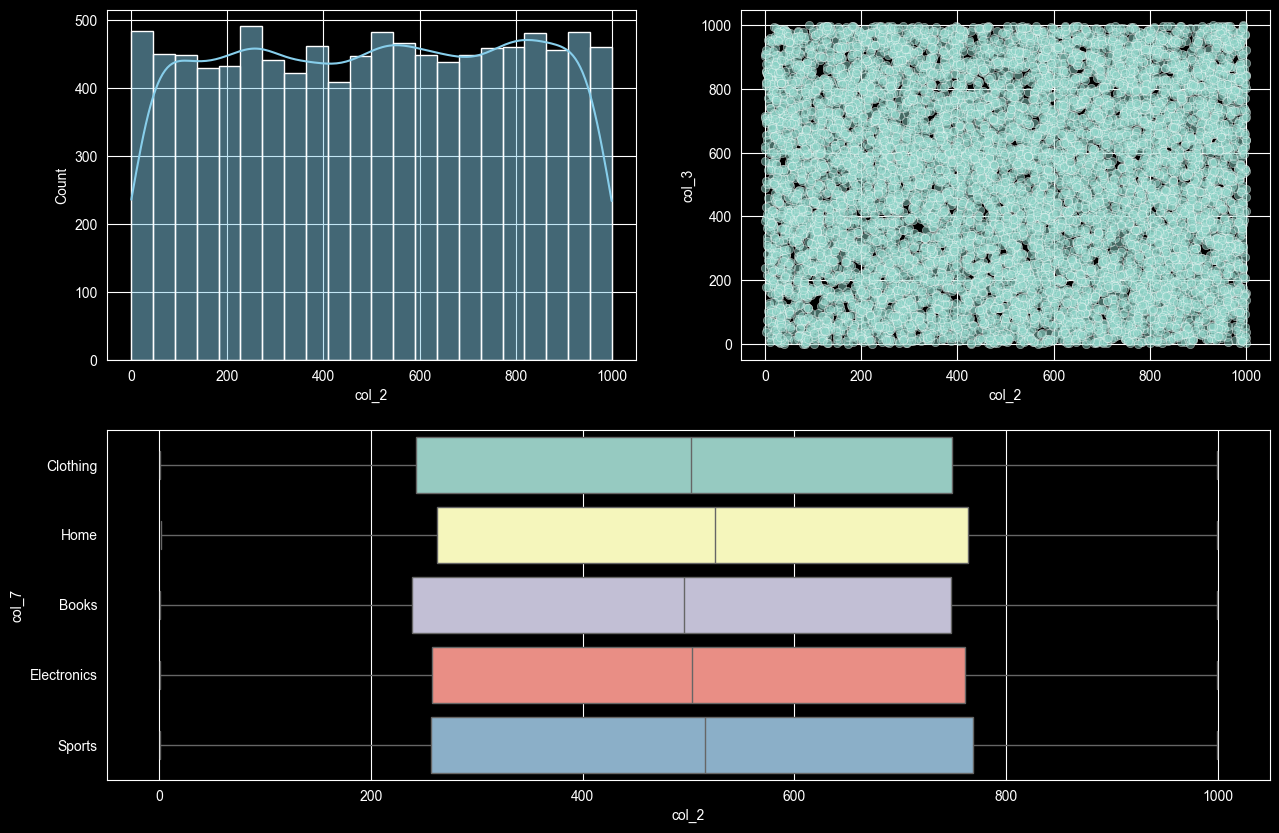

In [6]:
#4
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.histplot(df['col_2'], kde=True, color='skyblue')
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='col_2', y='col_3', alpha=0.5)
plt.subplot(2, 1, 2)
sns.boxplot(data=df, x='col_2', y ='col_7', hue='col_7')
plt.show()

In [7]:
#5
upper_limit = df['col_2'].mean() + 3 * df['col_2'].std()
lower_limit = df['col_2'].mean() - 3 * df['col_2'].std()
anomalies = df[(df['col_2'] > upper_limit) | (df['col_2'] < lower_limit)]
df_cleaned =df[(df['col_2'] <= upper_limit) & (df['col_2'] >= lower_limit)]
print(f"Количество найденных аномалий: {len(anomalies)}")
print(f"Размер таблицы после очистки: {df_cleaned.shape[0]} строк")

Количество найденных аномалий: 0
Размер таблицы после очистки: 10000 строк


In [8]:
#6
df_final = pd.get_dummies(df_cleaned, columns=['col_7'], prefix='cat', drop_first=True)
print(df_final.dtypes.head(10))
display(df_final.head())

col_1     object
col_2      int64
col_3      int64
col_4     object
col_5      int64
col_6      int64
col_8      int64
col_9      int64
col_10    object
col_11     int64
dtype: object


,col_1,col_2,col_3,col_4,col_5,col_6,col_8,col_9,col_10,col_11,...,col_48,col_49,col_50,total_value,double_stock,log_price,cat_Clothing,cat_Electronics,cat_Home,cat_Sports
0,Home,762,303,Electronics,49,348,206,123,Sports,597,...,484,Sports,643,230886,606,6.635947,True,False,False,False
1,Sports,190,34,Sports,107,99,836,775,Electronics,568,...,348,Home,603,6460,68,5.247024,True,False,False,False
2,Books,711,2,Home,93,876,868,69,Books,293,...,339,Sports,95,1422,4,6.566672,False,False,True,False
3,Sports,484,362,Books,636,361,897,111,Clothing,570,...,313,Electronics,593,175208,724,6.182085,False,False,True,False
4,Sports,733,195,Home,829,937,428,871,Home,9,...,784,Sports,44,142935,390,6.597146,True,False,False,False


In [23]:
#7
from sklearn.model_selection import train_test_split
y = df_final['col_2']
x = df_final.select_dtypes(include=['number']).drop(['col_2'], axis=1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Обучающая выборка: {x_train.shape[0]} строк")
print(f"Тестовая выборка: {x_test.shape[0]} строк")
print(f"Количество признаков: {x_train.shape[1]}")

Обучающая выборка: 8000 строк
Тестовая выборка: 2000 строк
Количество признаков: 35


In [26]:
#8
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
model = Ridge(alpha=1.0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"Средняя абсолютная ошибка (MAE): {mae:.2f}")
print(f"Среднеквадратичная ошибка (MSE): {mse:.2f}")

Средняя абсолютная ошибка (MAE): 79.04
Среднеквадратичная ошибка (MSE): 11171.99


/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid

In [32]:
#9
df_final['total_value'] = df_final['col_2'] * df_final['col_3']
df_final['double_stock'] = df_final['col_3'] * 2
x_multi = df_final.select_dtypes(include=['number']).drop(['col_2'], axis=1)
if 'log_price' in x_multi.columns:
    x_multi = x_multi.drop(['log_price'], axis=1)
x_train_m, x_test_m, y_train_m, y_test_m = train_test_split(x_multi, y, test_size=0.2, random_state=42)
model_multi = Ridge(alpha=1.0)
model_multi.fit(x_train_m, y_train_m)
y_pred_m = model_multi.predict(x_test_m)
mae_m = mean_absolute_error(y_test_m, y_pred_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)
print(f"MAE: {mae_m:.2f}")
print(f"MSE: {mse_m:.2f}")

MAE: 102.31
MSE: 20055.07


/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid

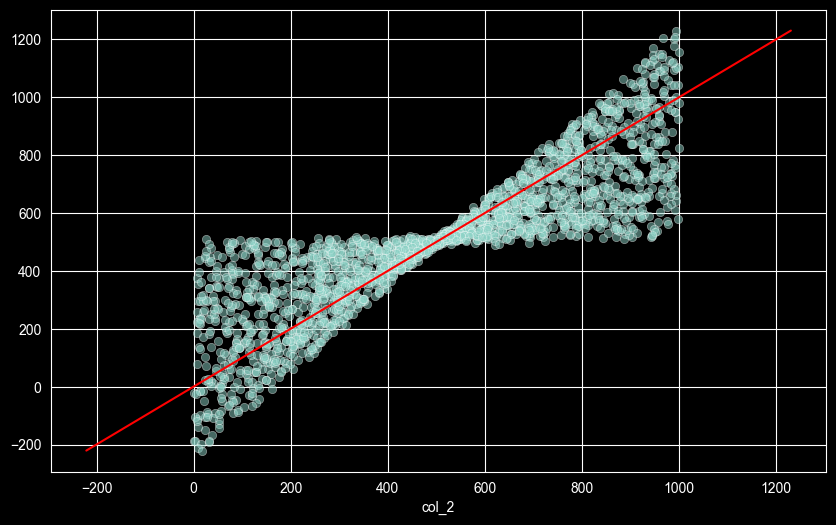

In [34]:
#10
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_m, y=y_pred_m, alpha=0.5)
min_val = min(y_test_m.min(), y_pred_m.min())
max_val = max(y_test_m.max(), y_pred_m.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')
plt.show()

In [36]:
#11
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
numeric_cols = ['col_3', 'total_value', 'double_stock']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_multi[numeric_cols])
print(f"Среднее после StandardScaler: {x_scaled.mean():.2f}")

Среднее после StandardScaler: -0.00


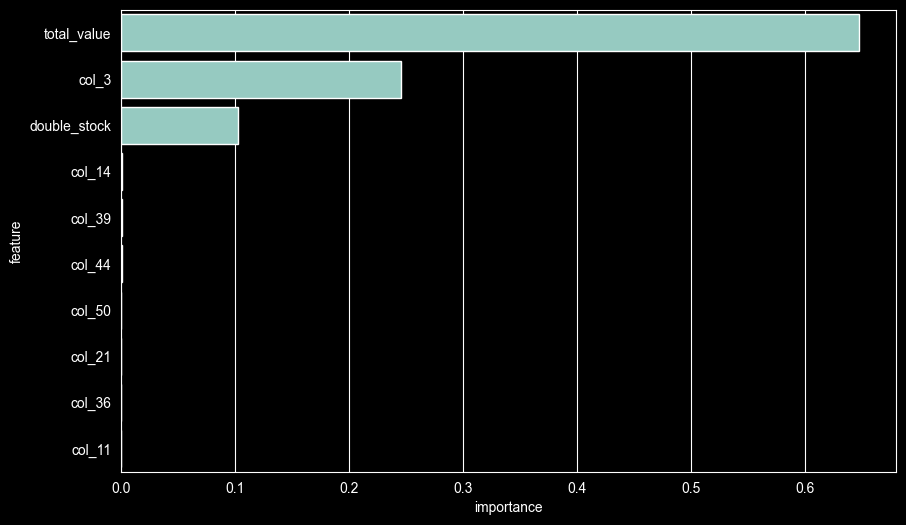

In [38]:
#12
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train_m, y_train_m)
importance = pd.DataFrame({'feature': x_multi.columns, 'importance': dt_model.feature_importances_})
importance = importance.sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance.head(10))
plt.show()

In [37]:
#13
poly = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly.fit_transform(x_scaled)
print(f"Количество признаков после Polynomial: {x_poly.shape[1]}")

Количество признаков после Polynomial: 9


In [39]:
#14
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
knn = KNeighborsRegressor(n_neighbors=5)
knn_cv_scores = cross_val_score(knn, x_scaled, y, cv=5, scoring='neg_mean_absolute_error')
print(f"Средний MAE на кросс-валидации (KNN): {-knn_cv_scores.mean():.2f}")

Средний MAE на кросс-валидации (KNN): 6.98


In [40]:
#15
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
categories = df_cleaned['col_7'].unique()
cat_results = []
for cat in categories:
    df_cat = df_final[df_cleaned['col_7'] == cat]
    if len(df_cat) > 20:
        y_cat = df_cat['col_2']
        x_cat = df_cat.select_dtypes(include=['number']).drop(['col_2'], axis=1)
        x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x_cat, y_cat, test_size=0.2, random_state=42)
        model_cat = LinearRegression()
        model_cat.fit(x_train_c, y_train_c)
        preds_cat = model_cat.predict(x_test_c)
        mae_cat = mean_absolute_error(y_test_c, preds_cat)
        cat_results.append({'Категория': cat, 'MAE': mae_cat, 'Кол-во товаров': len(df_cat)})
df_cat_metrics = pd.DataFrame(cat_results).sort_values(by='MAE')
print(df_cat_metrics)

     Категория        MAE  Кол-во товаров
2        Books  80.101146            1994
4       Sports  80.679413            2037
1         Home  81.150733            1968
3  Electronics  82.478281            2004
0     Clothing  85.388633            1997


/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/li

/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/li

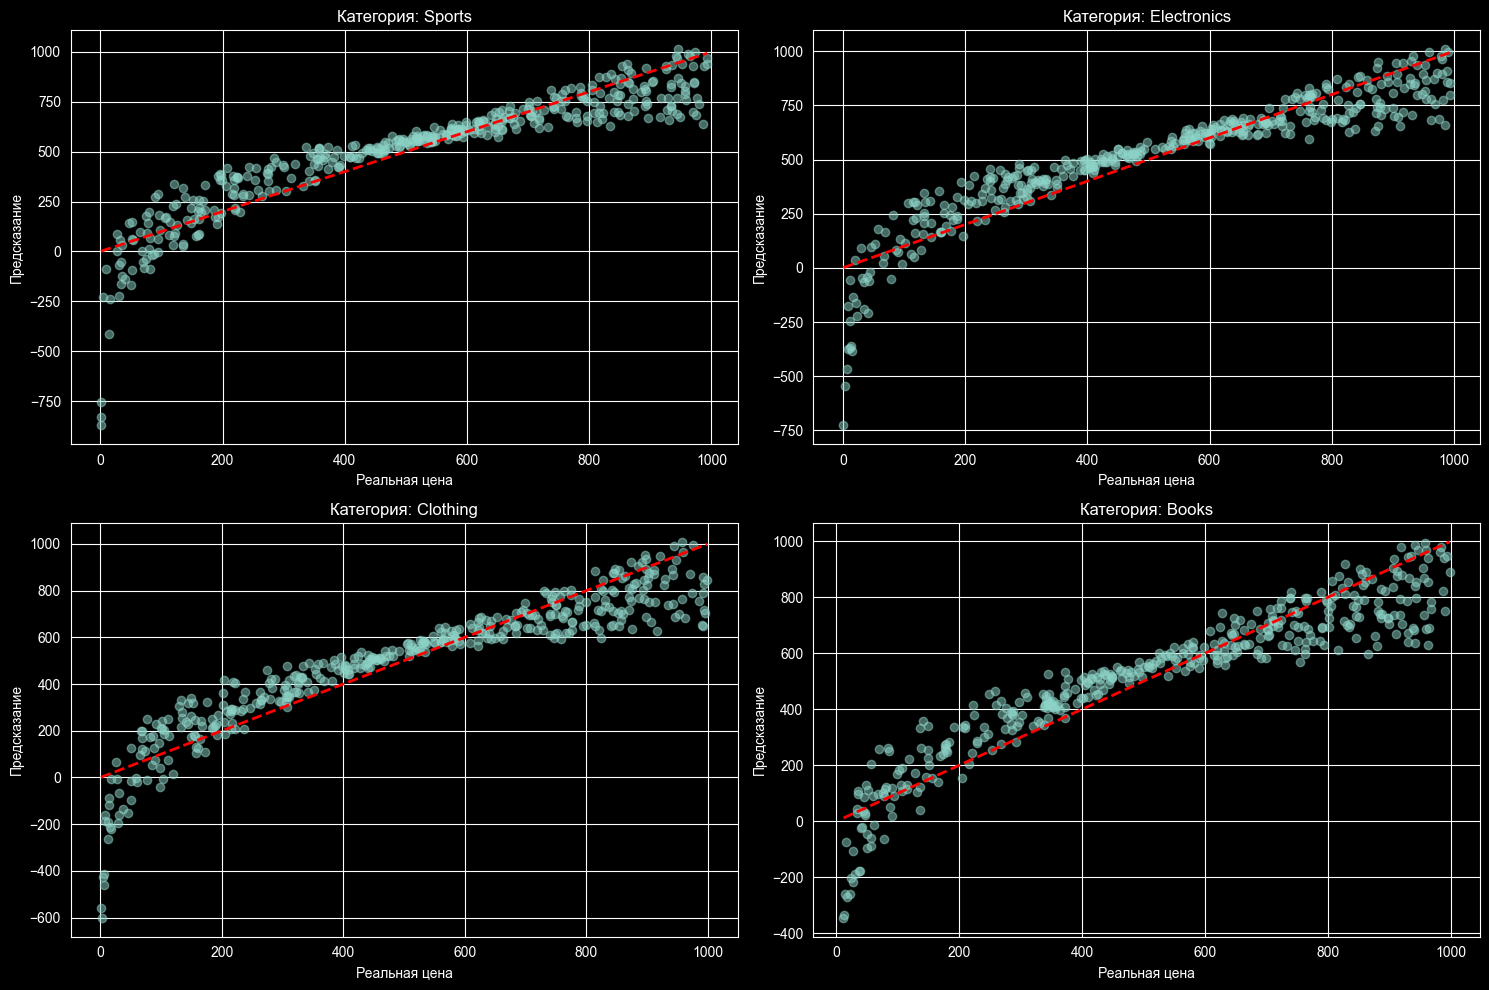


Самые большие ошибки в последней категории:
      Real        Pred        Diff
2010    12 -344.468099  356.468099
6179    13 -334.185153  347.185153
9341   962  628.809886  333.190114
3938   942  637.735152  304.264848
4791   930  638.977843  291.022157


In [41]:
#16
top_cats = df_cleaned['col_7'].value_counts().head(4).index
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, cat in enumerate(top_cats):
    df_cat = df_final[df_cleaned['col_7'] == cat]
    x_cat = df_cat.select_dtypes(include=['number']).drop(['col_2'], axis=1)
    y_cat = df_cat['col_2']
    x_tr, x_te, y_tr, y_te = train_test_split(x_cat, y_cat, test_size=0.2, random_state=42)
    model_cat = LinearRegression().fit(x_tr, y_tr)
    y_pr = model_cat.predict(x_te)
    axes[i].scatter(y_te, y_pr, alpha=0.5)
    axes[i].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
    axes[i].set_title(f'Категория: {cat}')
    axes[i].set_xlabel('Реальная цена')
    axes[i].set_ylabel('Предсказание')
plt.tight_layout()
plt.show()
error_df = pd.DataFrame({'Real': y_te, 'Pred': y_pr, 'Diff': abs(y_te - y_pr)})
print("\nСамые большие ошибки в последней категории:")
print(error_df.sort_values(by='Diff', ascending=False).head(5))

In [42]:
#17
from sklearn.model_selection import cross_val_score
model_cv = Ridge(alpha=1.0)
scores_mae = cross_val_score(model_cv, x_multi, y, cv=5, scoring='neg_mean_absolute_error')
scores_mse = cross_val_score(model_cv, x_multi, y, cv=5, scoring='neg_mean_squared_error')
print(f"MAE по фолдам: {-scores_mae}")
print(f"Средний MAE: {-scores_mae.mean():.2f} (+/- {scores_mae.std() * 2:.2f})")
print(f"Средний MSE: {-scores_mse.mean():.2f}")

MAE по фолдам: [101.18166179 103.44023524 103.01449715 105.91155611 107.32784547]
Средний MAE: 104.18 (+/- 4.36)
Средний MSE: 20761.26


/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid

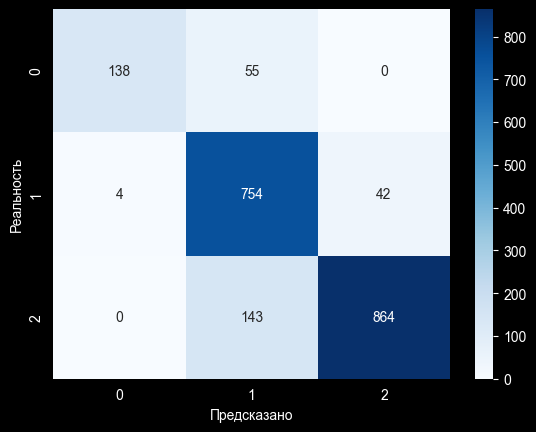

In [43]:
#18-19
from sklearn.metrics import confusion_matrix, accuracy_score
#18
def price_category(p):
    if p < 100: return 0
    elif p <= 500: return 1
    else: return 2
y_class = y.apply(price_category)
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=5)
clf.fit(x_train_m, y_train_m.apply(price_category))
#19
y_class_pred = clf.predict(x_test_m)
cm = confusion_matrix(y_test_m.apply(price_category), y_class_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.show()

In [44]:
#20
final_report = x_test_m.copy()
final_report['Real_Price'] = y_test_m
final_report['Predicted_Price'] = y_pred_m
final_report.to_excel("catalog_ml_predictions.xlsx", index=False)